# Country Borders Geometry

In this notebook, we analyze the geometry of European countries in residual-stream embedding space and compare geodesic "on-manifold" steering against linear steering on a relational geographic task ("which country borders Spain to the east?").

Research objective:
> Visualize geometrical organiation of European countries' representations when solving arithmetic geographic questions.
> Comparing geodesic steering against linear steering on a relational task whose answer-side representation forms a 2-D geographic map.

Research questions (RQs):
- **Task performance:** Can the model reliably solve the directional-border task at all?
- **Layer localization:** At which layer and token position is the answer-country variable mediated?
- **Subspace localization:** What's the lowest-dimensional subspace mediating most task-related variance?
- **Manifold localization:** Can we identify a two-dimensional manifold (the Europe map) that mediates the answer country?
- **Steering evaluation:** How does geometric vs linear steering affect output behavior between far countries (e.g. Spain → Russia)?

Our task is to select suitable interpretability methods to answer each RQ. Each RQ is an analysis that employs interpretability tools.
We build that analysis in a modular way to quickly iterate on hyperparameters defined in a config.


## Task performance

First we set up the task and measure whether the model reliably solves it at all. 
The causal model notebook [[link]] demonstrates how to set up tasks.
Here we've already set up the `country_borders` task: 30 European countries × 8 cardinal/intercardinal directions × 4 paraphrase templates, where the model has to retrieve the neighboring country in a given direction.
The task has been set up with a bunch of default configs. The runner config


In [ ]:
# Define the baseline config, save and load for printing

# # country_borders task with Gemma 3 12B-IT

# Convention: the defaults list is the source of truth for analysis steps.
# Each `- analysis/<step>` entry mounts that analysis at `cfg.<step>` (via
# `# @package <step>` in the analysis YAML). Add a top-level `<step>:` block
# only when you need to override fields.

baseline_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/baseline
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = train
  target_variable: country
  # Gemma 3 is a plain instruction-tuned model (no thinking channels), but
  # after chat-template wrapping the first generated token may be a leading
  # space or a SentencePiece sub-token; bump from the task default (1) to
  # give string_match enough generated content to match the country name.
  max_new_tokens: 8

baseline:
  visualization:
    figure_format: png
"""


from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

# Save the config overrides
path = save_runner_config(baseline_config_yaml, 'country_borders_baseline_demo')
print(f'Written to {path}\n')

# Load the full hydra config
cfg = load_runner_config('country_borders_baseline_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

In [ ]:
# Run the baseline analysis.
#
# Chat templating: Gemma 3 12B-IT is an instruction-tuned model. The model
# config's `use_chat_template: true` flag is read by `load_pipeline` and
# forwarded to `LMPipeline`, which wraps each raw_input with
# `apply_chat_template([{role: user, content: text}], add_generation_prompt=True)`
# at tokenize-time (no client-side rendering, no /tmp file). The chat-formatted
# prompt ends in `<start_of_turn>model\n`, so the existing
# `last_token: position: -1` in tasks/country_borders/token_positions.py
# already captures the last token before answer generation.
import os
import causalab
import subprocess

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_baseline_demo"],
    cwd=project_root,
)

if rc.returncode == 0:
    print("\n\nBaseline analysis ran successfully!")

In [55]:
import json
import os

artifact_dir = os.path.join(project_root, cfg.experiment_root, 'baseline')
print(f'Artifact directory: {artifact_dir}\n')
print('Contents:', sorted(os.listdir(artifact_dir)))

Artifact directory: /workspace/causalab/artifacts/country_borders/llama31_8b_instruct/baseline

Contents: ['accuracy.json', 'confusion_heatmap.png', 'counterfactual_sanity.json', 'full_output_dists.safetensors', 'ground_truth_dim0.png', 'metadata.json', 'per_class_output_dists.safetensors', 'test_samples.json', 'top_logits.json', 'train_samples.json']


In [56]:
# Show task samples 

with open(os.path.join(artifact_dir, 'train_samples.json')) as f:
    train_samples = json.load(f)['samples']
print(json.dumps(train_samples[:3], indent=2))

[
  {
    "raw_input": "Q: Which country lies to the north of France?\nA:",
    "raw_output": " Belgium"
  },
  {
    "raw_input": "Q: What country borders France on the north?\nA:",
    "raw_output": " Belgium"
  },
  {
    "raw_input": "Q: To the north of France is the country of\nA:",
    "raw_output": " Belgium"
  }
]


In [57]:
# Show task accuracy

with open(os.path.join(artifact_dir, 'accuracy.json')) as f:
    print(json.dumps(json.load(f), indent=2))

{
  "accuracy": 0.3927083333333333,
  "correct": 377,
  "total": 960,
  "prob_accuracy": 0.25917460090082994
}


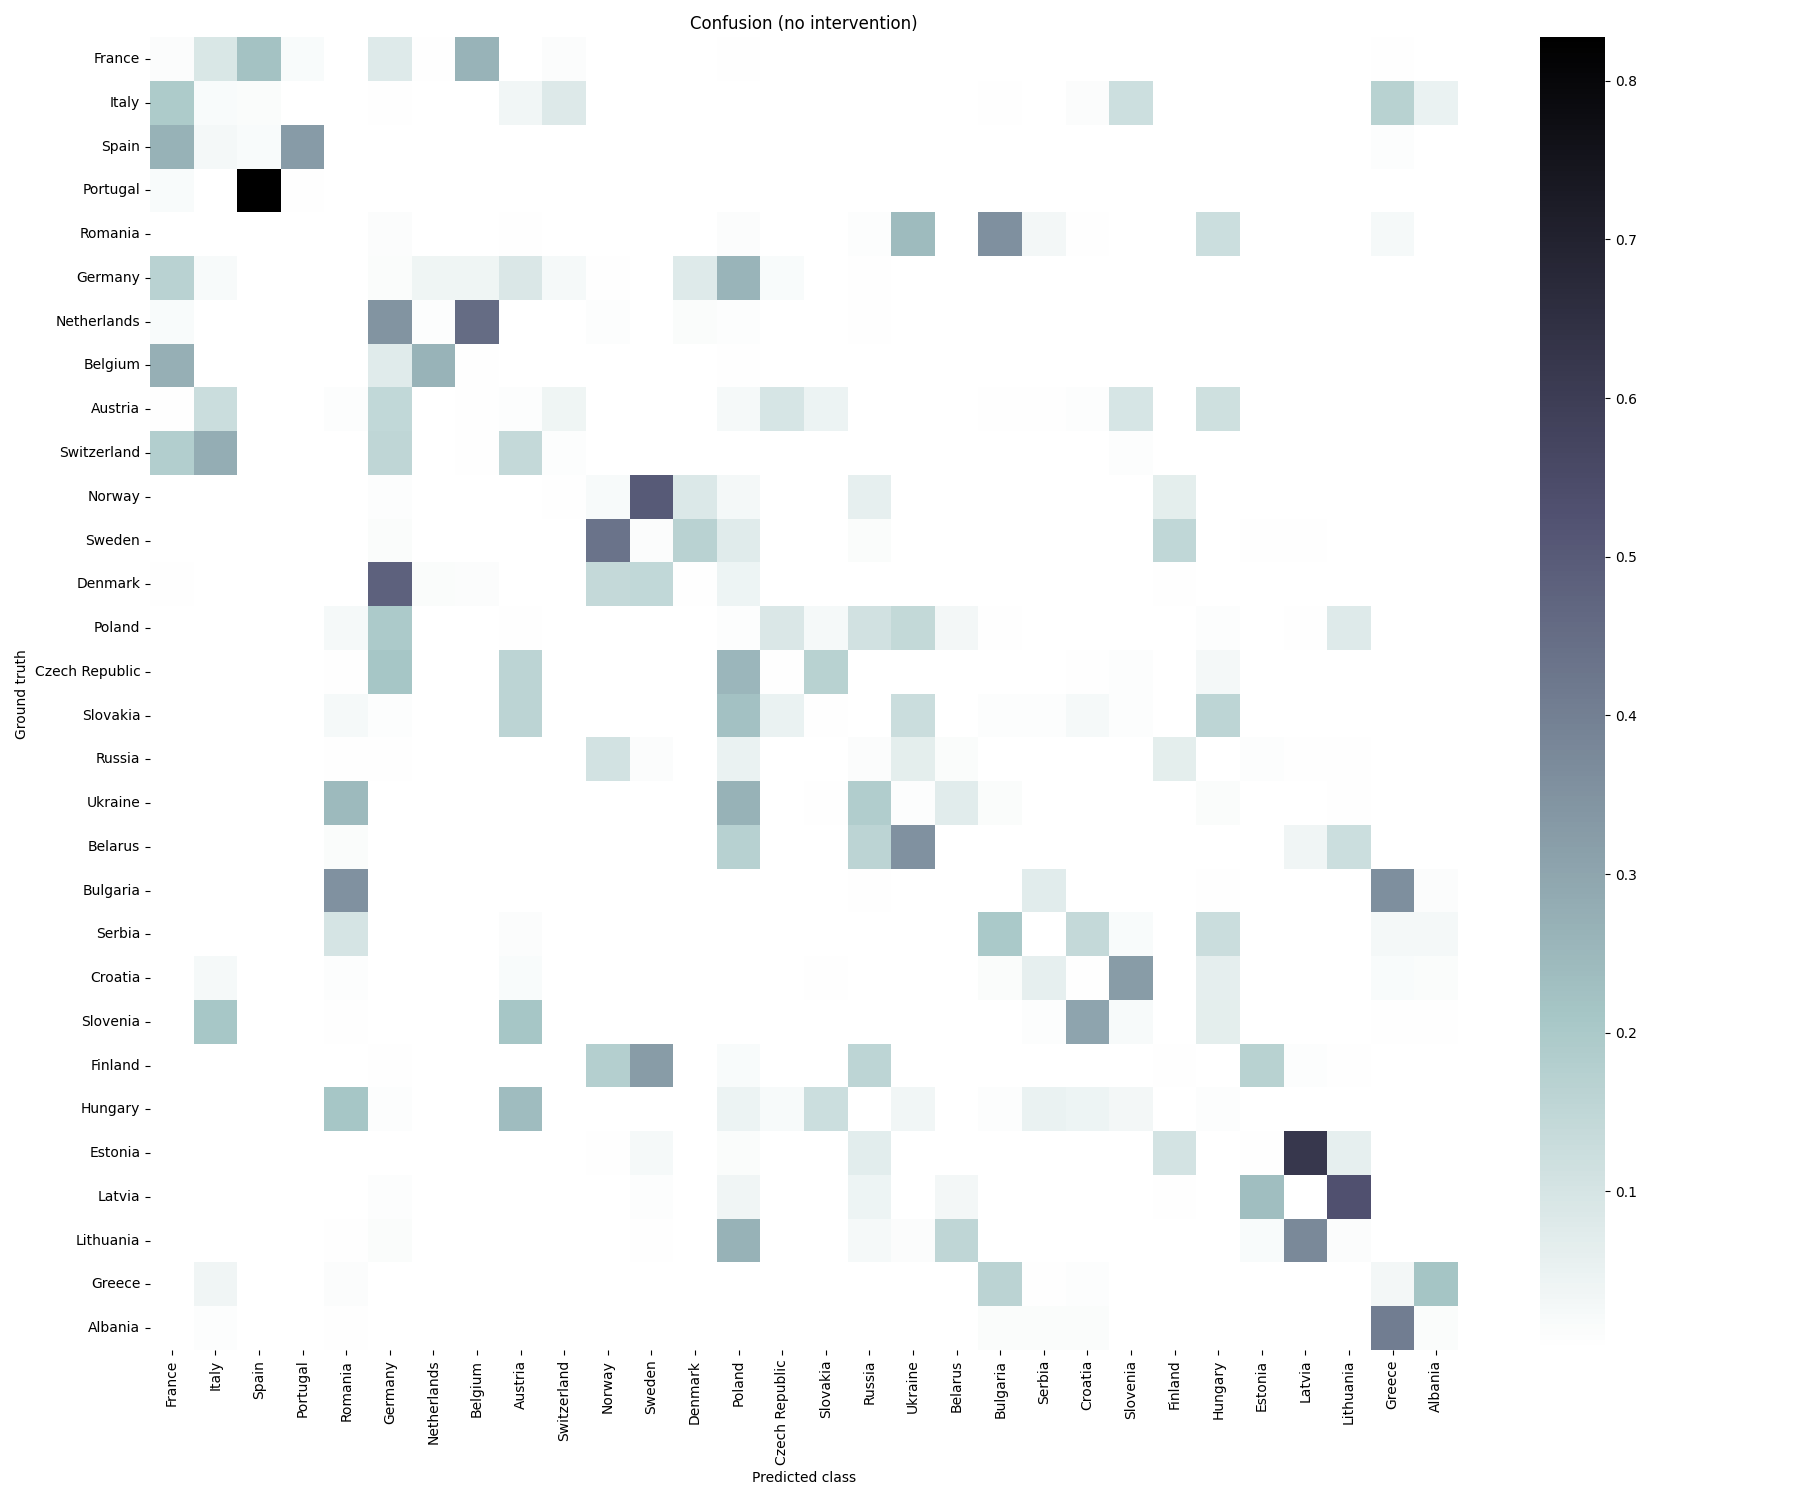

In [58]:
# Show the heatmap of the confusion matrix, with an extra column that aggregates the mass on task-unrelated tokens. 

from IPython.display import Image, display
with open(os.path.join(artifact_dir, 'confusion_heatmap.png')) as f:
    display(Image(filename=f.name))

For Gemma 3 12B-IT, the confusion matrix shows the model is concentrated on a handful of frequently-correct neighbors, with a long tail of mistakes biased toward geographically-plausible countries — consistent with the model carrying a coherent geographic representation that is more accurate than the strict baseline score implies (584 prompts have ≥1 valid neighbor; ground-truth uses the primary canonical neighbor).

## Layer localization

Now that we know Gemma 3 12B-IT solves the task, we ask **where** in the residual stream the answer-country variable is encoded.
The `locate` analysis patches activations from counterfactual inputs at each (layer, token_position) cell and measures how well the intervention recovers the expected causal effect.
See the `locate` demo notebook [[link]] for the full walkthrough; here we use the same config as the country_borders reference run.

In [ ]:
# Define the locate config, save and load for printing
#
# Gemma 3 12B has 48 transformer layers — wider sweep than the 32-layer
# Llama-8B baseline.

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: country
  target_variable: country

locate:
  method: interchange
  mode: pairwise
  layers: [0, 8, 16, 24, 32, 40]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'country_borders_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('country_borders_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

In [62]:
# Run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_locate_demo"],
    cwd=project_root,
)

[2026-05-20 16:50:57,894][__main__][INFO] - === Step: locate (locate) ===
[2026-05-20 16:51:25,945][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B-Instruct (device=cuda)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 98.18it/s]


[2026-05-20 16:51:29,420][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['country']
[2026-05-20 16:51:29,425][causalab.analyses.locate.main][INFO] - === Locate: target_variable=country ===
[2026-05-20 16:51:29,836][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=country)
[2026-05-20 16:51:29,844][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 39.3%
[2026-05-20 16:51:29,847][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([30, 30])
[2026-05-20 16:51:29,848][causalab.methods.interchange.layer_scan][INFO] - Collecting counterfactual output distributions...
[2026-05-20 16:51:43,509][causalab.methods.interchange.layer_scan][INFO] - Collecting features for 18 targets in a single pass...


Pairwise layer scan: 100%|██████████| 18/18 [04:35<00:00, 15.30s/it]


[2026-05-20 16:56:27,060][causalab.analyses.locate.main][INFO] - country: best cell = (layer=8, position=country), score=0.2042
[2026-05-20 16:56:27,191][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=country)
[2026-05-20 16:56:59,744][causalab.analyses.locate.main][INFO] - Single-pair trace saved to artifacts/country_borders/llama31_8b_instruct/locate/interchange/single_pair_trace.json
[2026-05-20 16:57:00,529][causalab.analyses.locate.main][INFO] - Locate analysis complete. Output in artifacts/country_borders/llama31_8b_instruct/locate/interchange


CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_locate_demo'], returncode=0)

In [63]:
locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)
print(f'Locate artifact directory: {locate_artifact_dir}\n')
print('Contents:', sorted(os.listdir(locate_artifact_dir)))

Locate artifact directory: /workspace/causalab/artifacts/country_borders/llama31_8b_instruct/locate/interchange

Contents: ['country', 'metadata.json', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.png']


Base prompt:           Q: Which country lies to the north of France?
A:
Counterfactual prompt: Q: Which country lies to the north of Croatia?
A:



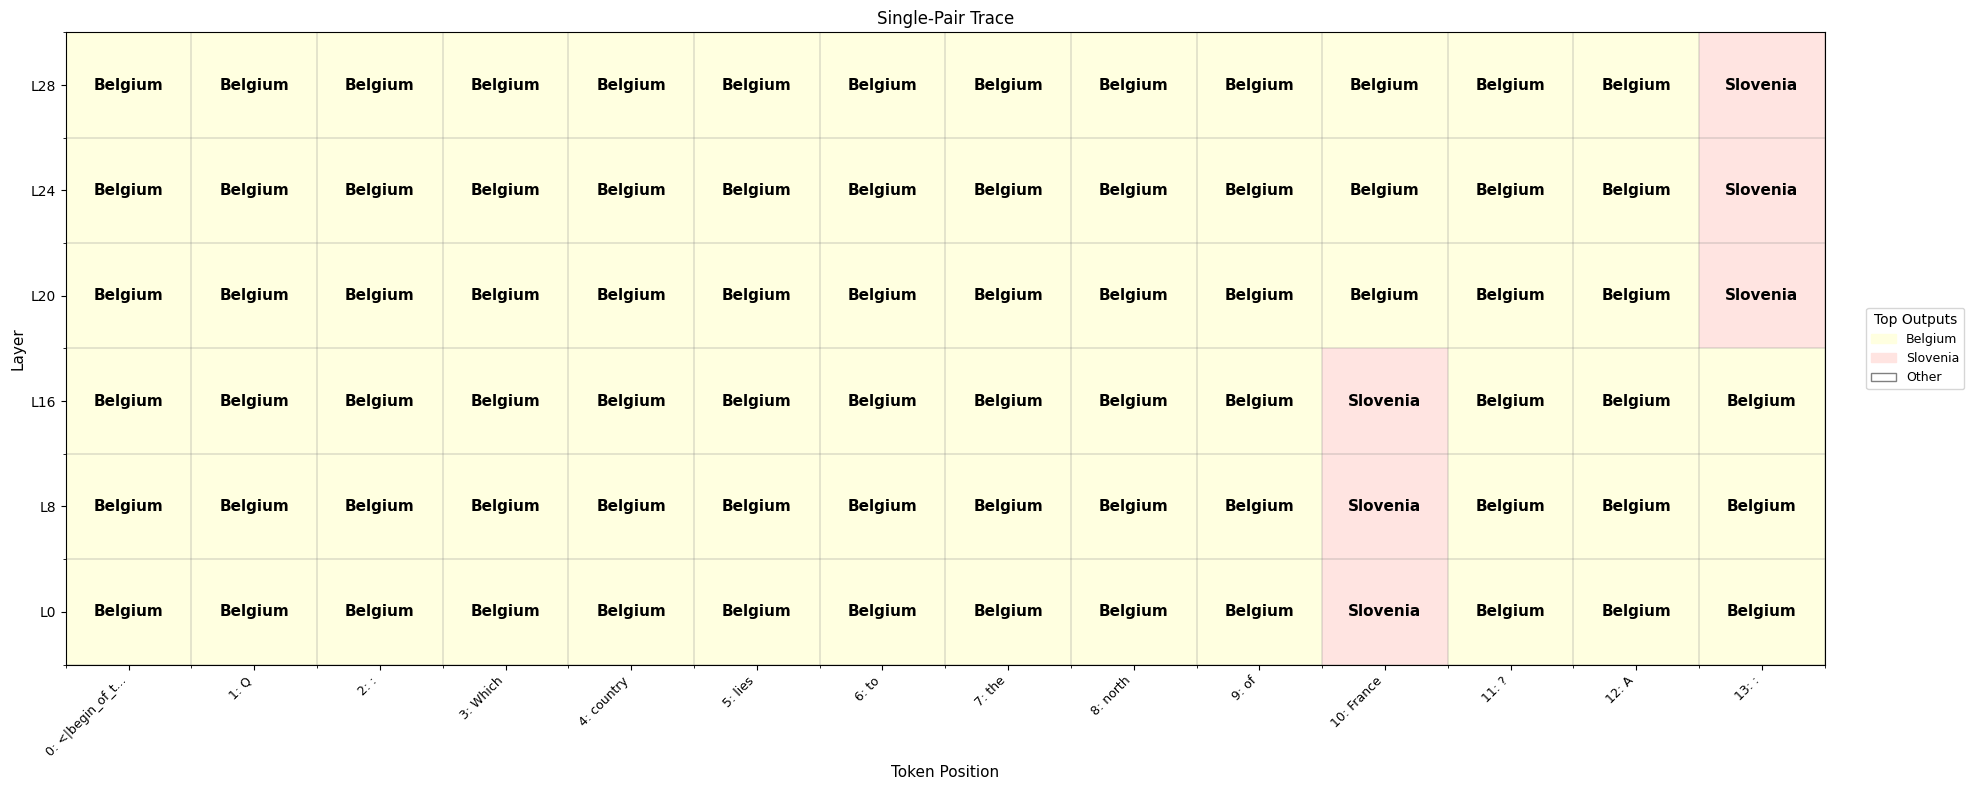

In [64]:
# Show the single-pair trace: what the model outputs at every (layer, token_position) when one counterfactual pair is patched.
# Look for where the signal "hops" from the input token to the last token across layers.

import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(locate_artifact_dir, 'single_pair_trace.json')
with open(trace_path) as f:
    trace_data = json.load(f)

print(f"Base prompt:           {trace_data['prompt']}")
print(f"Counterfactual prompt: {trace_data['counterfactual_prompt']}\n")

plot_single_pair_trace_heatmap(trace_data, figure_format='png')


--- country ---


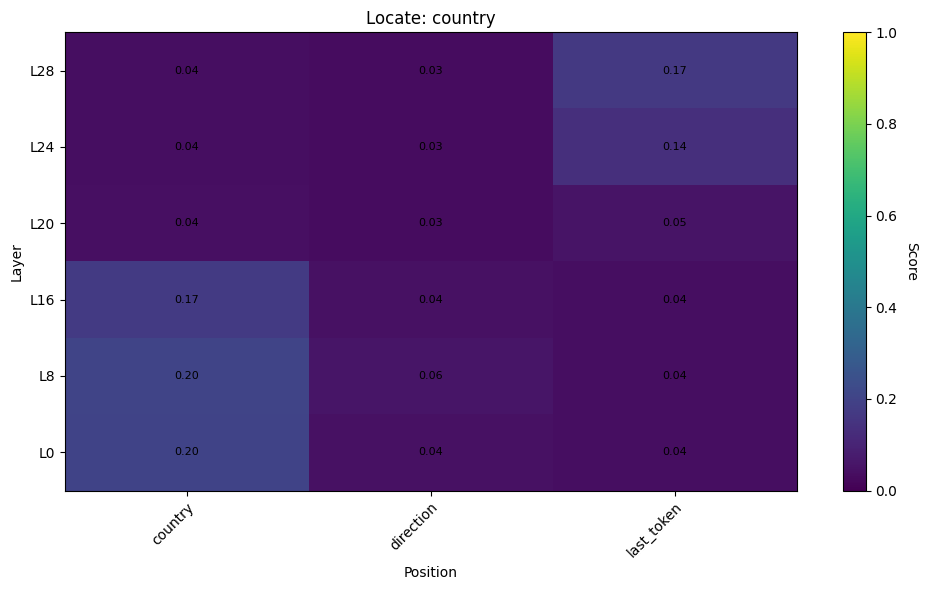

In [65]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

The heatmap localizes the answer-country variable to a small region of (layer, token_position) cells. Information about the queried country enters early at the country token and is routed toward the last token, where the unembedding reads it out. This gives us the (layer, position) target for the next RQ — finding the low-dimensional subspace within that cell.

Now, we're specifically interested in patching centroids. Before, we were defining (base, source) counterfactual pairs and checking whether the patch successfully steered the model from base to source prediction. 
Instead, we now compute one centroid per *answer country* (averaging over all (entity, direction) prompts whose primary neighbor is that country) and check whether intervening with a source centroid robustly steers the answer, regardless of the specific input. This averages out information about the entity and direction, since many (entity, direction) cells share the same answer country (e.g. France can be the answer for Spain→NE, Belgium→S, Germany→W, ...).

We're switching to centroid mode and resample all variables.


In [ ]:
# Defining the centroid patching config.

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: all # <-- changing to all variables, since we don't use counterfactual pairs anyways, the centroids will be our counterfactual pairs.
  target_variable: country

locate:
  method: interchange
  mode: centroid # <-- changing to centroid mode
  layers: [0, 8, 16, 24, 32, 40]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'country_borders_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('country_borders_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

In [67]:
# Re-run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_locate_demo"],
    cwd=project_root,
)

[2026-05-20 16:57:06,134][__main__][INFO] - === Step: locate (locate) ===
[2026-05-20 16:57:40,683][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B-Instruct (device=cuda)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 106.57it/s]


[2026-05-20 16:57:44,369][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['country']
[2026-05-20 16:57:44,374][causalab.analyses.locate.main][INFO] - === Locate: target_variable=country ===
[2026-05-20 16:57:44,732][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=all)
[2026-05-20 16:57:44,741][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 39.3%
[2026-05-20 16:57:44,747][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([30, 30])


Centroid layer scan: 100%|██████████| 18/18 [01:43<00:00,  5.73s/it]


[2026-05-20 16:59:28,961][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/llama31_8b_instruct/locate/interchange/country/L0/Plast_token/patched_dim0.png
[2026-05-20 16:59:28,962][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/country_borders/llama31_8b_instruct/locate/interchange/country/L0/Plast_token/patched_dim0.png
[2026-05-20 16:59:29,550][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/llama31_8b_instruct/locate/interchange/country/L0/Pcountry/patched_dim0.png
[2026-05-20 16:59:29,551][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/country_borders/llama31_8b_instruct/locate/interchange/country/L0/Pcountry/patched_dim0.png
[2026-05-20 16:59:30,153][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/llama31_8b_instruct/locate/interchange/country/L0/Pdirection/patched_dim0.png
[2026-05-2

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_locate_demo'], returncode=0)


--- country ---


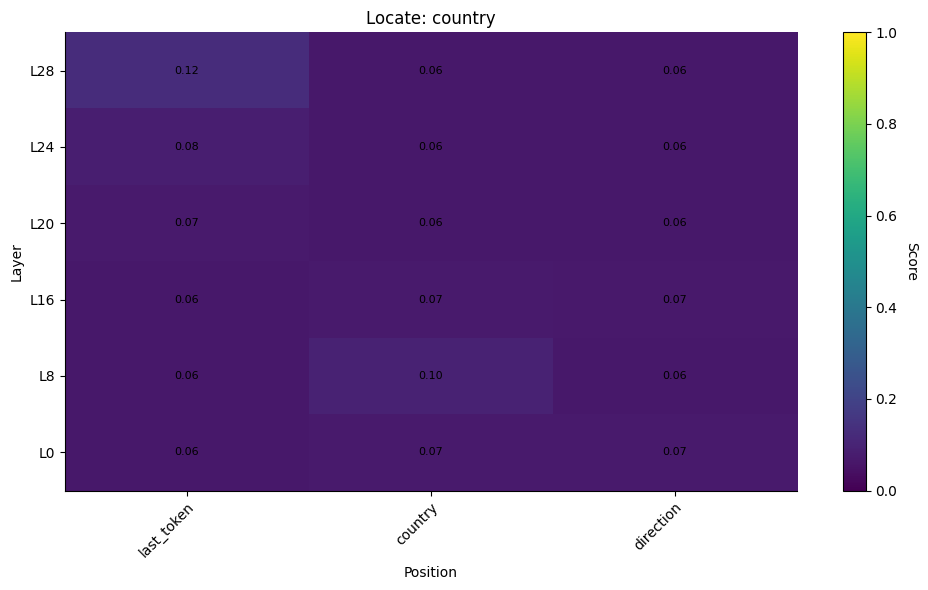

In [68]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

We've learned that centroid intervention works at the final token position at layer 28 (the canonical site studied in the original geometry result). Let's fix our following investigation to this site in the model.
Next, we want to identify whether a low-dimensional subspace captures most variance.


## Subspace localization

"Subspace that captures most variance" can mean two (or more?) things each requiring its own tool: 
- **Input variance:** Subspace that captures most variance of activations for all inputs --> PCA
- **Output variance:** Subspace that is most causally relevant to flip a model prediction from the base answer to a counterfactual source answer.

In the end we are concerned with steering model behavior, so causal efficacy is highly relevant and DAS is a suitable tool.
However, in our current approach we are patching centroids over all inputs and don't define counterfactual pairs, so PCA is a natural choice for subspace identification with this approach.

`country_borders` task with Gemma 3 12B-IT.

In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/subspace
  - _self_
task:
  enumerate_all: true # training on all possible examples, test = train
  target_variable: country

subspace:
  method: pca
  # Late-middle layer on Gemma 3 12B (48 layers); update after inspecting
  # the locate heatmap above.
  layers: [36]
  k_features: 32
  token_positions: [last_token]
  visualization:
    figure_format: png
"""


save_runner_config(config_yaml, 'country_borders_subspace_demo')
cfg = load_runner_config('country_borders_subspace_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

In [70]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_subspace_demo"],
    cwd=project_root
)

[2026-05-20 17:00:16,224][__main__][INFO] - === Step: subspace (subspace) ===
[2026-05-20 17:00:47,187][__main__][INFO] - Running analysis: subspace | target_variable: country
[2026-05-20 17:00:47,583][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=all)
[2026-05-20 17:00:47,743][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B-Instruct (device=cuda)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 104.43it/s]


[2026-05-20 17:00:51,597][causalab.analyses.subspace.pca][INFO] - Computing PCA with k=32...


[2026-05-20 17:01:09,106][causalab.analyses.subspace.pca][INFO] - PCA variance explained: ['51.8%', '20.7%', '9.5%', '2.4%', '2.0%', '1.2%', '0.9%', '0.8%', '0.7%', '0.6%', '0.5%', '0.4%', '0.4%', '0.3%', '0.3%', '0.3%', '0.3%', '0.3%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%', '0.1%'], total: 95.8%
[2026-05-20 17:01:09,593][causalab.methods.spline.builders][INFO] - Computed 30 centroids from 960 samples (params: ['country_0', 'country_1'])
[2026-05-20 17:01:10,597][causalab.io.plots.plot_3d_interactive][INFO] - Saved artifacts/country_borders/llama31_8b_instruct/subspace/pca_k32/country/visualization/features_3d.html
[2026-05-20 17:01:10,598][causalab.analyses.subspace._visualization][INFO] - Saved features_3d.html to artifacts/country_borders/llama31_8b_instruct/subspace/pca_k32/country/visualization
[2026-05-20 17:01:10,623][causalab.methods.spline.builders][INFO] - Computed 30 centroids from 960 samples (params: ['countr

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_subspace_demo'], returncode=0)

In [71]:
# Locate subspace artifact directory.
# Outputs are nested under <step>/<method_subdir>/<target_variable>/...
subspace_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'subspace',
    f"{cfg.subspace.method}_k{cfg.subspace.k_features}",
    cfg.task.target_variable,
)
vis_dir = os.path.join(subspace_artifact_dir, 'visualization')
print(f'Visualization directory: {vis_dir}')
print('Contents:', sorted(os.listdir(vis_dir)))

Visualization directory: /workspace/causalab/artifacts/country_borders/llama31_8b_instruct/subspace/pca_k32/country/visualization
Contents: ['features_2d.png', 'features_3d.html', 'features_3d.png', 'features_variance.png']


### Variance explained by the PCA subspace

Each bar shows the **cumulative** variance explained by the first k principal components,
as a fraction of the **total variance of the full embedding space** — the denominator is
the sum of all singular values squared, not just the k-component subspace.
A steep early rise means the representation is intrinsically low-dimensional.
The dashed line marks how much total variance the chosen k_features subspace retains.


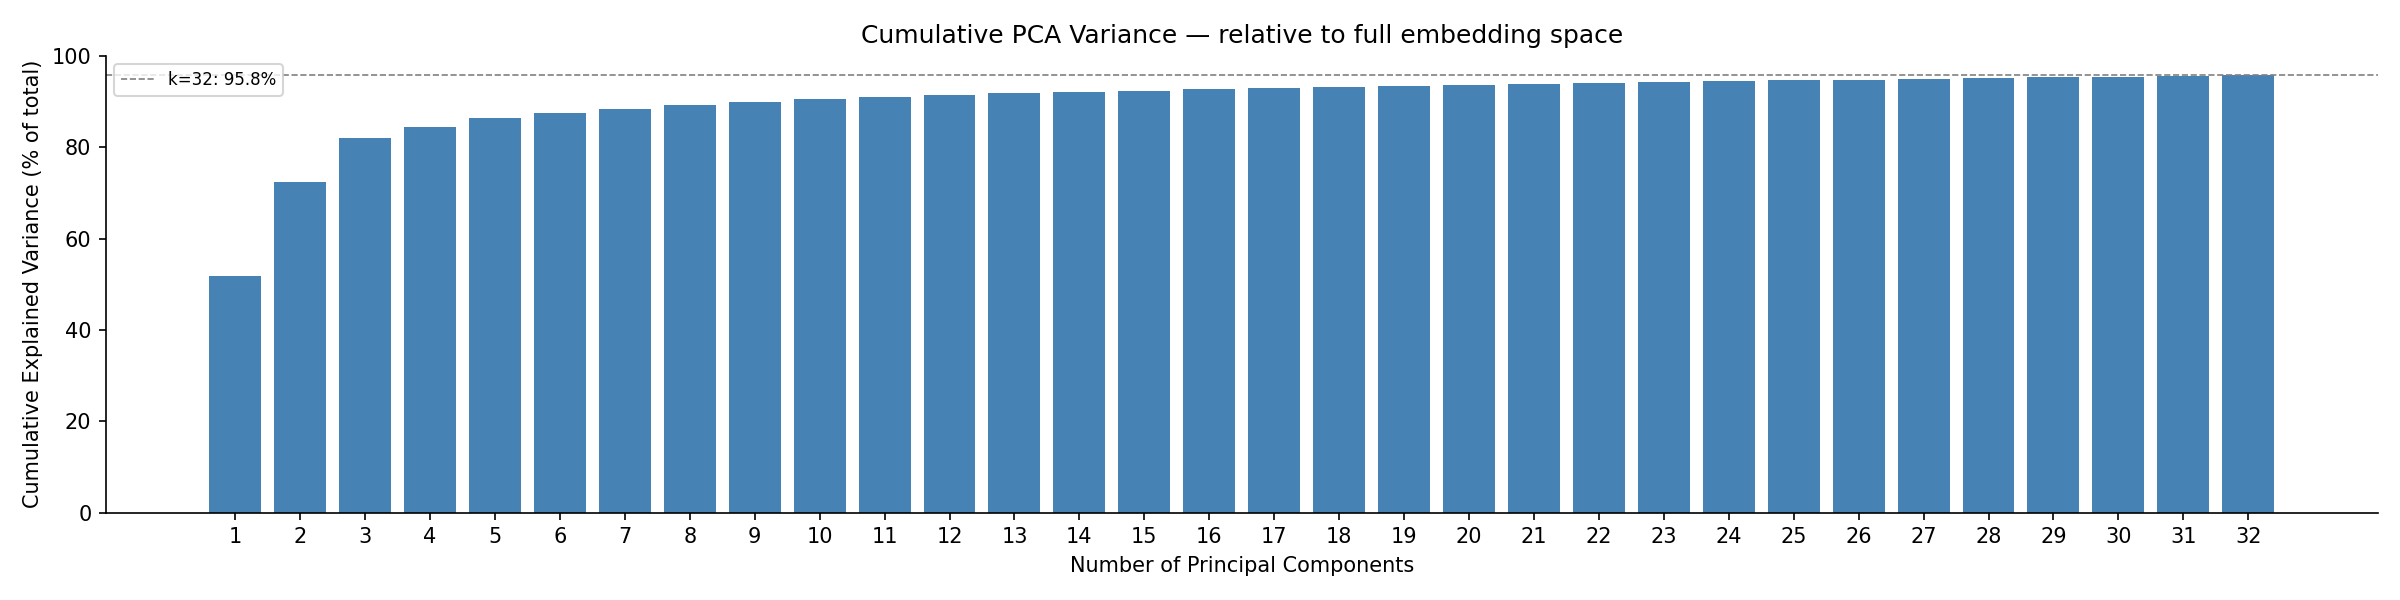

In [72]:
# Cumulative explained variance vs. number of PCs
display(Image(filename=os.path.join(vis_dir, 'features_variance.png')))

The first three PCs typically capture most of the structure (on Llama-3.1-8B the cumulative was ≈53% / 22% / 9% ≈ 84%; Gemma 3 12B-IT has a similar shape with slightly different magnitudes after chat-template wrapping), so `k_features=32` is comfortably above the elbow.

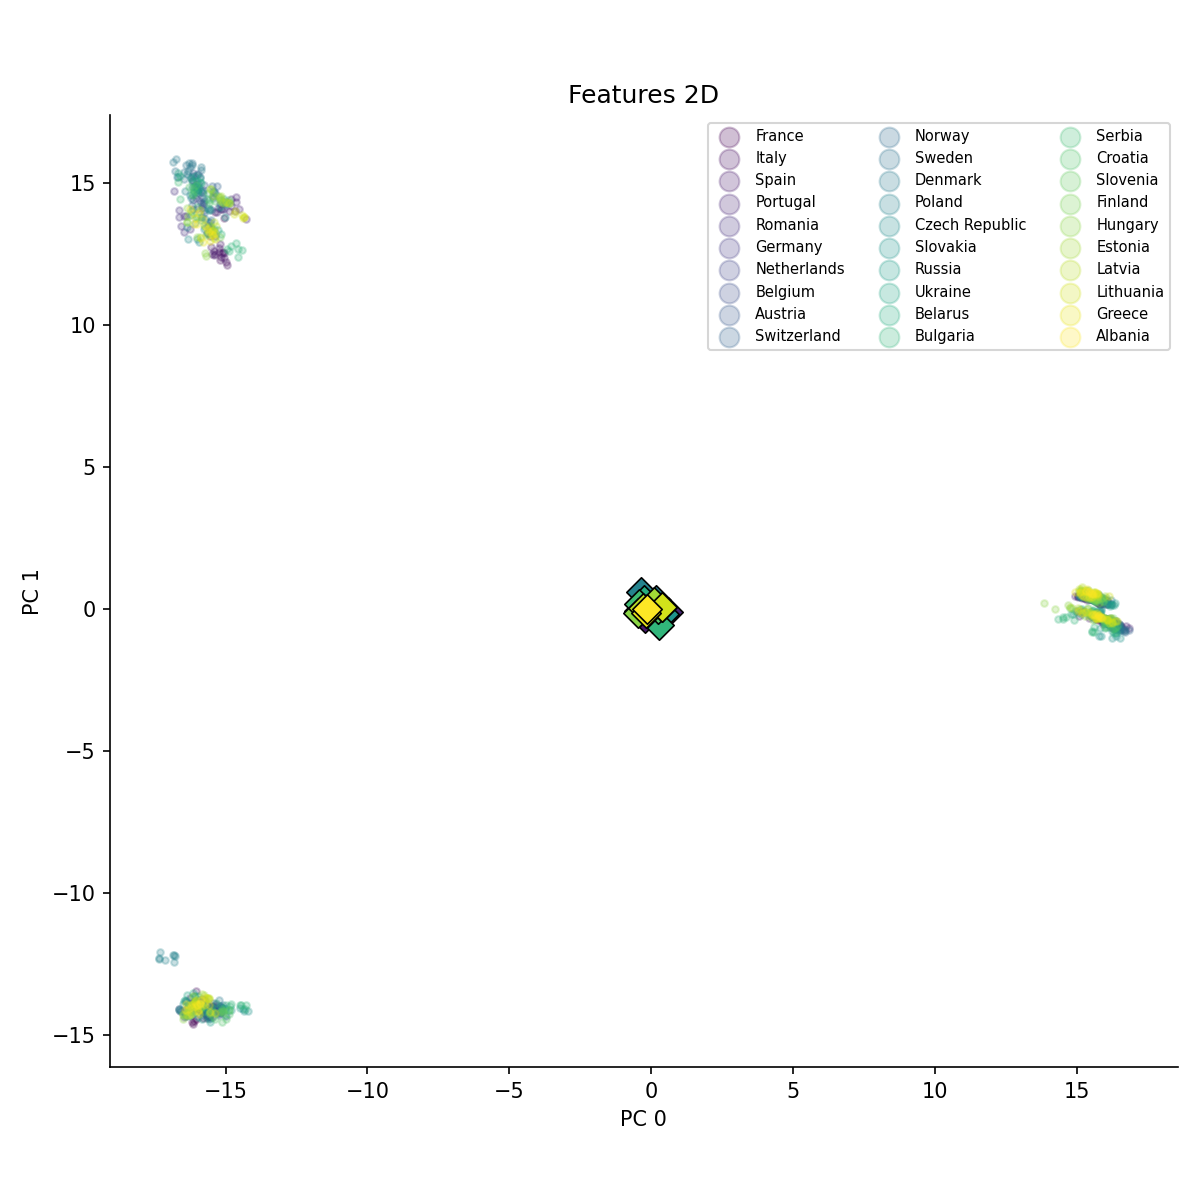

In [73]:
# 2D PCA scatter: training examples colored by weekday
display(Image(filename=os.path.join(vis_dir, 'features_2d.png')))

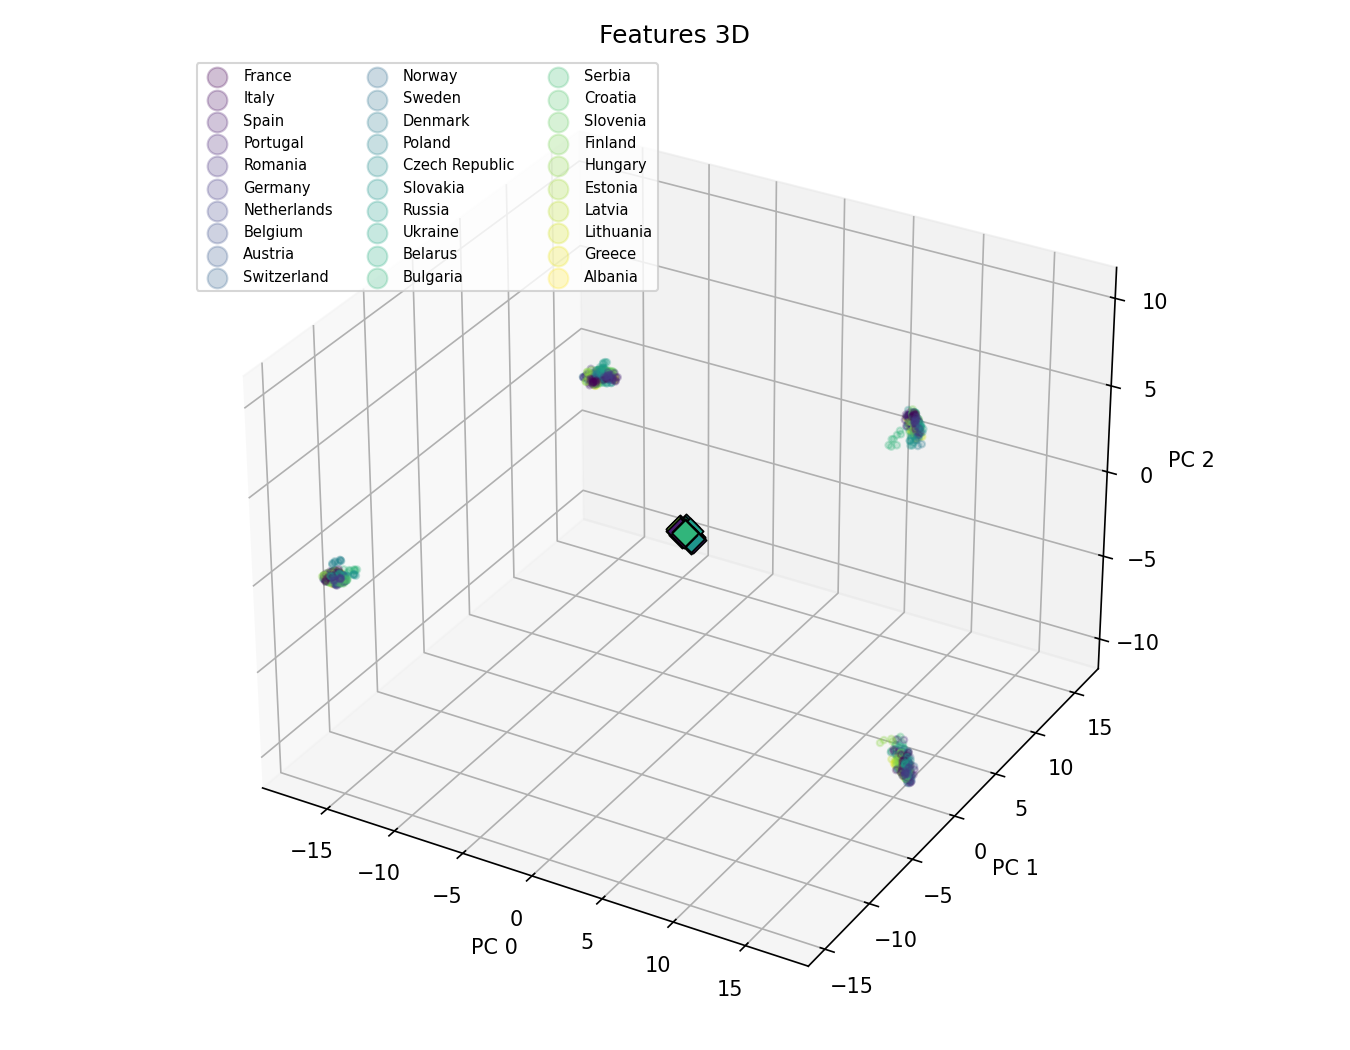

In [74]:
# Static 3D PCA scatter (matplotlib): PC0 x PC1 x PC2
display(Image(filename=os.path.join(vis_dir, 'features_3d.png')))

PC0: R^2=0.763
PC1: R^2=0.848
PC2: R^2=0.076


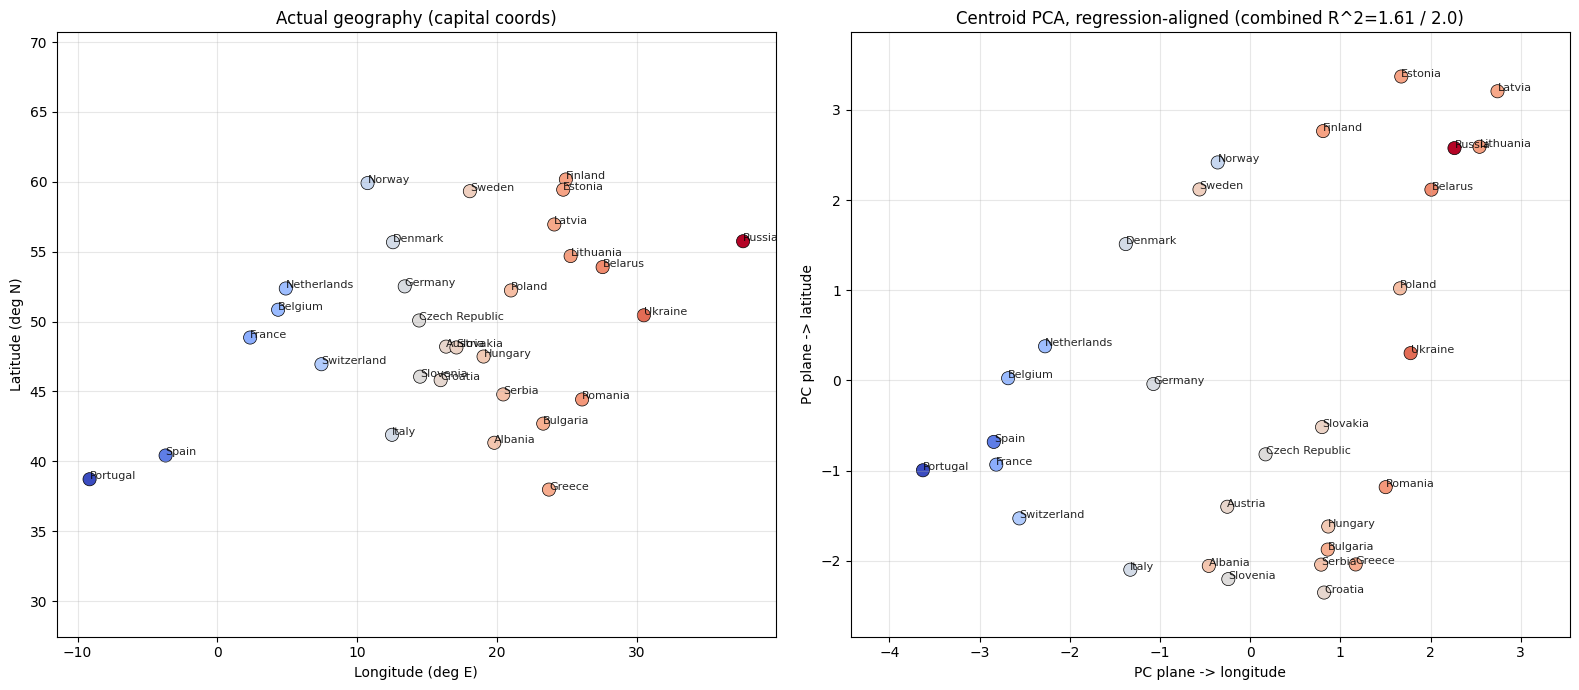

In [75]:
# Side-by-side: actual European geography vs the model's centroid PCA plane,
# regression-aligned to (lon, lat). Centroids are per ANSWER country (primary
# neighbor) — entity-disentangled averaging. France's centroid pools all
# prompts whose answer is France: (Spain, NE), (Italy, NW), (Germany, W), ...

import json
import numpy as np
import matplotlib.pyplot as plt
from safetensors.torch import load_file
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from causalab.tasks.country_borders import COUNTRIES, NEIGHBOR_OF, LAT_LON_OF

try:
  from adjustText import adjust_text
except ImportError:
  adjust_text = None  # fall back to plain annotate; pip install adjustText for better labels

# 1. Load PCA-32 features + the row-aligned train dataset.
features = load_file(
  os.path.join(subspace_artifact_dir, "features", "training_features.safetensors")
)["features"].float().numpy()
with open(os.path.join(subspace_artifact_dir, "train_dataset.json")) as f:
  rows = json.load(f)

# 2. Map each row to its ANSWER country (primary neighbor). Rows whose
#    (country, direction) is not in NEIGHBOR_OF are invalid and skipped.
by_answer: dict[str, list[int]] = {}
for i, r in enumerate(rows):
  key = (r["input"]["country"], r["input"]["direction"])
  if key in NEIGHBOR_OF:
      by_answer.setdefault(NEIGHBOR_OF[key][0], []).append(i)

  names = [c for c in COUNTRIES if c in by_country]
  centroids = np.stack([features[by_country[c]].mean(0) for c in names])

names = [c for c in COUNTRIES if c in by_answer]
centroids = np.stack([features[by_answer[c]].mean(0) for c in names])
lats = np.array([LAT_LON_OF[c][0] for c in names])
lons = np.array([LAT_LON_OF[c][1] for c in names])
geo = np.column_stack([lats, lons])

# 3. PCA(3) over centroids; print per-PC R^2 with geography.
P = PCA(n_components=3).fit_transform(centroids)
for k in range(3):
  r2 = LinearRegression().fit(geo, P[:, k]).score(geo, P[:, k])
  print(f"PC{k}: R^2={r2:.3f}")

# 4. Regression-aligned axes: find the directions in the (PC0, PC1) plane
#    that point geographic "east" and "north", project onto them. This is
#    correct by construction — no manual rotation/sign-flip needed.
east  = LinearRegression().fit(P[:, :2], lons).coef_
north = LinearRegression().fit(P[:, :2], lats).coef_
east  /= np.linalg.norm(east)
north /= np.linalg.norm(north)
disp_x = P[:, :2] @ east     # longitude-like
disp_y = P[:, :2] @ north    # latitude-like

# Rotation-invariant quantity we already had.
combined_r2 = sum(
  LinearRegression().fit(geo, P[:, k]).score(geo, P[:, k]) for k in range(2)
)

# 5. Side-by-side plot, colored by longitude so the eye can match panels.
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
panels = [
  (lons, lats, "Longitude (deg E)", "Latitude (deg N)",
   "Actual geography (capital coords)"),
  (disp_x, disp_y, "PC plane -> longitude", "PC plane -> latitude",
   f"Centroid PCA, regression-aligned (combined R^2={combined_r2:.2f} / 2.0)"),
]
for axi, (xs, ys, xl, yl, title) in zip(ax, panels):
  axi.scatter(xs, ys, s=90, c=lons, cmap="coolwarm",
              edgecolors="black", linewidths=0.5)
  texts = [
      axi.annotate(name, (x, y), fontsize=8, alpha=0.85)
      for name, x, y in zip(names, xs, ys)
  ]
  if adjust_text is not None:
      adjust_text(
          texts, ax=axi,
          arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
          expand_points=(1.2, 1.4),
      )
  axi.set(xlabel=xl, ylabel=yl, title=title)
  axi.set_aspect("equal", adjustable="datalim")
  axi.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Activation manifold fitting

We'll use a thin-plate spline parameterized by capital `[lat, lon]` (the task exposes this via the `country` variable's embedding) to fit a smooth 2-D manifold through the 30 country centroids.


In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/activation_manifold
  - _self_
task:
  target_variable: country
activation_manifold:
  manifold_intrinsic_coords: parameter
  method: spline
  smoothness: 0.0
  subspace: pca_k32
  k_features: 32
  skip_decoding_eval: false
  # Match subspace's layer above.
  layers: [36]
  token_positions: [last_token]
  visualization:
    figure_format: png
""" 

save_runner_config(config_yaml, 'country_borders_activation_manifold_demo')
cfg = load_runner_config('country_borders_activation_manifold_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

In [ ]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_activation_manifold_demo"],
    cwd=project_root,
)

In [ ]:
# Find the manifold_3d.png — artifact dir is nested under activation_manifold/
from glob import glob

manifold_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'visualization', 'manifold_3d.png',
), recursive=True))
print('Found:', manifold_pngs)

In [ ]:
# Static 3D manifold: scatter colored by weekday + fitted spline curve
display(Image(filename=manifold_pngs[0]))

Because the manifold is a continuous 2-D spline, we can steer the model to any (lat, lon) point on it —
intrinsic-space positions between any two centroids (e.g. Spain → Russia, passing near Italy/Austria/Ukraine)
give us geographic steering targets across the European map. This manifold-traversal
evaluation is now produced by the **`path_steering`** analysis (the natural follow-up to
`activation_manifold`); its heatmaps show how each country token's output probability
evolves as we walk the geodesic.
Re-run with `path_steering` in the runner config to regenerate this section.


In [ ]:
# Continuous manifold steering: x-axis labels show weekday names at centroid positions;
# unlabelled ticks between them are interpolated intrinsic-space positions.

steering_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'manifold_steering', 'manifold_steering_dim0.png',
), recursive=True))
print('Found:', steering_pngs)

if steering_pngs:
    display(Image(filename=steering_pngs[0]))

## Path steering: geodesic vs linear

With the activation manifold fitted, we steer the model from Spain to Russia along two paths:
- **Geodesic**: follows the fitted spline in intrinsic (lat, lon) coordinates — stays on the manifold
- **Linear**: straight line between the two centroids in PCA space — cuts through embedding space

We restrict to a single far pair (Spain → Russia) to compare the output distributions produced by each path.


In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_12b_it
  - /analysis/path_steering
  - _self_
task:
  target_variable: country
path_steering:
  subspace: pca_k32
  # Include the L{layer}_{token_position} cell-segment that
  # activation_manifold writes when token_positions is set, so the loader
  # finds the spline featurizer instead of falling back to identity.
  # Must match the layer chosen in subspace/activation_manifold above.
  activation_manifold: L36_last_token/spline_s0.0
  selected_pairs: [["Spain", "Russia"]]
  path_modes: [geometric, linear]
  visualization:
    figure_format: png
"""

save_runner_config(config_yaml, 'country_borders_path_steering_demo')
cfg_ps = load_runner_config('country_borders_path_steering_demo')
print('Full hydra config:\n', OmegaConf.to_yaml(cfg_ps))

In [ ]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_path_steering_demo"],
    cwd=project_root,
)

In [ ]:
# Path-steering artifacts are nested under <subspace>/<manifold>/<target_variable>/...
ps_out_dir = os.path.join(
    project_root, cfg_ps.experiment_root,
    'path_steering',
    cfg_ps.path_steering.subspace,
    cfg_ps.path_steering.activation_manifold,
    cfg_ps.task.target_variable,
)

In [ ]:
# 3D PCA space: geodesic (black) vs linear (gray) path from Monday to Thursday.
# The 3D plot is saved as an interactive HTML (plotly), not a static image.
from IPython.display import IFrame
path_3d_html = os.path.join(ps_out_dir, 'vis', 'paths', '3d_paths', 'Spain_Russia.html')
print(path_3d_html)
IFrame(src=path_3d_html, width='100%', height=600)

In [ ]:
# Geodesic path: output probability landscape stepping along the manifold
geo_img = os.path.join(ps_out_dir, 'vis', 'paths', 'geometric', 'pair_Spain_Russia.png')
display(Image(filename=geo_img))

In [ ]:
# Linear path: output probability landscape stepping through raw PCA space
lin_img = os.path.join(ps_out_dir, 'vis', 'paths', 'linear', 'pair_Spain_Russia.png')
display(Image(filename=lin_img))